# Decision Tree Classification with Principal Component Analysis

In [1]:
# imports libaries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [5]:
# Load data & train/test split
df = pd.read_csv("datasets/DEEP-Q2-tree_pca_exam_data.csv")
X = df.drop("y", axis=1).values
y = df["y"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)
print(f"Dataset: {X.shape[0]} Samples, {X.shape[1]} Features")
print(f"Train: {len(X_train)}  ||  Test: {len(X_test)}")
print(f"Missing values : {df.isnull().sum().sum()}")
df.head()

Dataset: 2400 Samples, 10 Features
Train: 1800  ||  Test: 600
Missing values : 0


,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,y
0,0.213623,-1.101614,2.324822,2.504061,-1.606930,4.125178,1.982070,-1.481034,0.640186,1.834961,1
1,-2.309379,-0.480536,0.369304,3.702126,-3.079824,0.223345,-0.286878,0.926305,-0.336874,-1.348247,1
2,-0.665245,1.641626,0.332758,1.025954,-1.874350,3.068696,-1.665427,-0.101051,0.914842,0.555564,1
3,1.089730,-0.019354,0.646028,2.256308,-1.215445,1.572121,0.452762,0.702141,2.928323,-1.508915,1
4,1.644076,1.463309,0.624989,-0.124951,-1.255044,3.287014,-1.202619,-1.170605,-2.231827,2.509437,1


### (a). Raw Features:
A Decision Tree Classifier was trained on the raw dataset using a 75/25 train-test split, with tree depth varied from 1 to 20. The highest test accuracy achieved was 84.83% at a maximum depth of 3, which did not meet the 85% accuracy threshold.


In [6]:
# (a) Raw features 
print(" Raw features — accuracy by depth")
print("_" * 50)

raw_accs = {}
dmin_raw = None

for d in range(1, 21):
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    acc = clf.score(X_test, y_test)
    raw_accs[d] = acc
    print(f"  depth={d:2d}:  acc = {acc:.4f}")
    if acc >= 0.85 and dmin_raw is None:
        dmin_raw = d
        print(f"  *** dmin = {d}, accuracy = {acc:.4f} ***")

if dmin_raw is None:
    best_d = max(raw_accs, key=raw_accs.get)
    print("_" * 45)
    print(f"  85% threshold NOT reached on raw features.")
    print(f"  Best: depth={best_d}, accuracy={raw_accs[best_d]:.4f}")

 Raw features — accuracy by depth
__________________________________________________
  depth= 1:  acc = 0.7567
  depth= 2:  acc = 0.8150
  depth= 3:  acc = 0.8483
  depth= 4:  acc = 0.8450
  depth= 5:  acc = 0.8333
  depth= 6:  acc = 0.8183
  depth= 7:  acc = 0.8267
  depth= 8:  acc = 0.8117
  depth= 9:  acc = 0.8000
  depth=10:  acc = 0.7950
  depth=11:  acc = 0.7983
  depth=12:  acc = 0.8017
  depth=13:  acc = 0.7967
  depth=14:  acc = 0.8017
  depth=15:  acc = 0.7917
  depth=16:  acc = 0.7983
  depth=17:  acc = 0.7900
  depth=18:  acc = 0.7917
  depth=19:  acc = 0.7917
  depth=20:  acc = 0.7917
_____________________________________________
  85% threshold NOT reached on raw features.
  Best: depth=3, accuracy=0.8483


### (b). Preprocessing and PCA: 
A Decision Tree Classifier was trained on the raw dataset using a 75/25 train-test split, with tree depth varied from 1 to 20. The highest test accuracy achieved was 84.83% at a maximum depth of 3, which did not meet the 85% accuracy threshold.


In [7]:
print(" StandardScaler + PCA — d_min by number of components")
print("_" * 50)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Show explained variance for context
pca_full = PCA(random_state=42).fit(X_train_sc)
evr_cum = np.cumsum(pca_full.explained_variance_ratio_)
print("  Cumulative explained variance ratio by component:")
for i, v in enumerate(evr_cum, 1):
    print(f"    k={i}: {v:.3f}")

candidate_ks = [1, 2, 3, 4, 5, 6, 8, 10]
max_k = min(X_train_sc.shape[0], X_train_sc.shape[1])
valid_ks = [k for k in candidate_ks if k <= max_k]
print("_" * 50)
print(f"  Max valid PCA components = {max_k}")
print("_" * 50)
print(f"  Testing k values: {valid_ks}")

for k in valid_ks:
    pca = PCA(n_components=k, random_state=42)
    Xtr = pca.fit_transform(X_train_sc)
    Xte = pca.transform(X_test_sc)
    evr = pca.explained_variance_ratio_.sum()

    dmin_pca = None
    best_acc = 0.0

    for d in range(1, 21):
        clf = DecisionTreeClassifier(max_depth=d, random_state=42)
        clf.fit(Xtr, y_train)
        acc = clf.score(Xte, y_test)
        best_acc = max(best_acc, acc)

        if acc >= 0.85:
            dmin_pca = d
            print(f"  k={k:2d} (EVR={evr:.3f}):  dmin={d}, acc={acc:.4f}")
            break

    if dmin_pca is None:
        print(f"  k={k:2d} (EVR={evr:.3f}):  85% NOT reached — best={best_acc:.4f}")

invalid_ks = [k for k in candidate_ks if k > max_k]
if invalid_ks:
    print("_" * 50)
    print(f"Skippedd invalid k values: {invalid_ks}")


 StandardScaler + PCA — d_min by number of components
__________________________________________________
  Cumulative explained variance ratio by component:
    k=1: 0.371
    k=2: 0.587
    k=3: 0.666
    k=4: 0.744
    k=5: 0.814
    k=6: 0.876
    k=7: 0.929
    k=8: 0.969
    k=9: 0.988
    k=10: 1.000
__________________________________________________
  Max valid PCA components = 10
__________________________________________________
  Testing k values: [1, 2, 3, 4, 5, 6, 8, 10]
  k= 1 (EVR=0.371):  85% NOT reached — best=0.8250
  k= 2 (EVR=0.587):  85% NOT reached — best=0.8250
  k= 3 (EVR=0.666):  85% NOT reached — best=0.8250
  k= 4 (EVR=0.744):  85% NOT reached — best=0.8283
  k= 5 (EVR=0.814):  85% NOT reached — best=0.8250
  k= 6 (EVR=0.876):  85% NOT reached — best=0.8250
  k= 8 (EVR=0.969):  85% NOT reached — best=0.8250
  k=10 (EVR=1.000):  85% NOT reached — best=0.8433


 Accuracy depth curves: k ∈ {1, 2, 8}
__________________________________________________
 k=1: [0.825, 0.825, 0.823, 0.812, 0.818, 0.817, 0.802, 0.788, 0.783, 0.78, 0.782, 0.785, 0.775, 0.763, 0.752]
 k=2: [0.825, 0.825, 0.822, 0.812, 0.813, 0.802, 0.793, 0.785, 0.772, 0.778, 0.763, 0.752, 0.752, 0.758, 0.753]
 k=8: [0.825, 0.825, 0.823, 0.81, 0.795, 0.817, 0.788, 0.767, 0.772, 0.732, 0.73, 0.737, 0.74, 0.733, 0.737]


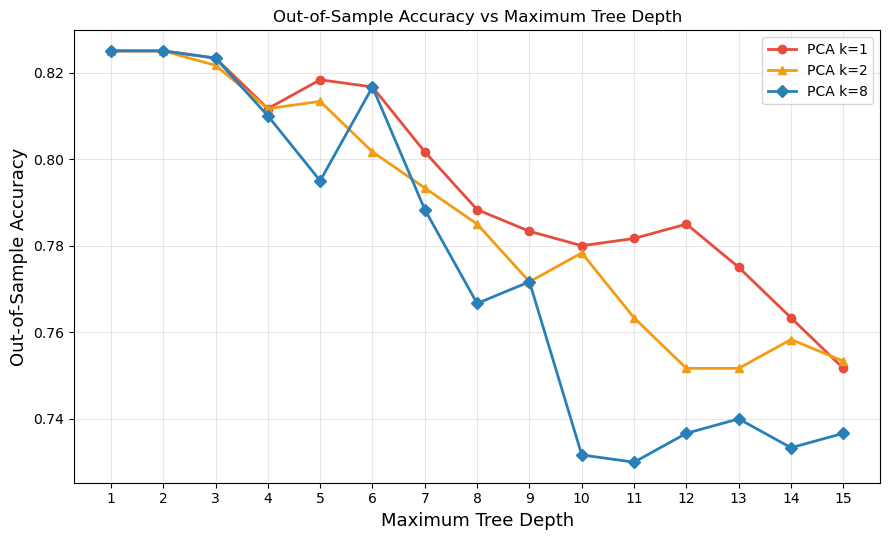

In [8]:
print(" Accuracy depth curves: k ∈ {1, 2, 8}")
print("_" * 50)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

depths = list(range(1, 16))
candidate_ks = [1, 2, 8]
max_k = min(X_train_sc.shape[0], X_train_sc.shape[1])
ks = [k for k in candidate_ks if k <= max_k]

colors  = {1: "#e74c3c", 2: "#f39c12", 8: "#2980b9"}
markers = {1: "o",       2: "^",       8: "D"}

pca_accs = {}
for k in ks:
    pca = PCA(n_components=k, random_state=42)
    Xtr = pca.fit_transform(X_train_sc)
    Xte = pca.transform(X_test_sc)

    accs = []
    for d in depths:
        clf = DecisionTreeClassifier(max_depth=d, random_state=42)
        clf.fit(Xtr, y_train)
        accs.append(clf.score(Xte, y_test))
    pca_accs[k] = accs
    print(f" k={k}: {[round(a, 3) for a in accs]}")

if len(ks) < len(candidate_ks):
    skipped = [k for k in candidate_ks if k > max_k]
    print(f" Skipped invalid k values: {skipped}")

fig, ax = plt.subplots(figsize=(9, 5.5))

for k in ks:
    ax.plot(
        depths, pca_accs[k],
        marker=markers[k], color=colors[k], linewidth=2, markersize=6,
        label=f"PCA k={k}"
    )

ax.set_xlabel("Maximum Tree Depth", fontsize=13)
ax.set_ylabel("Out-of-Sample Accuracy", fontsize=13)
ax.set_title("Out-of-Sample Accuracy vs Maximum Tree Depth", fontsize=12)
ax.set_xticks(depths)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()
